In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import os
all_paper = pd.read_excel('all_A_papers_innovation.xlsx')
award_0_index = all_paper[all_paper['award'] == 0].index
award_1_index = all_paper[all_paper['award'] == 1].index
award_0_stats = []
award_1_stats = []
# 从data目录下读取{i}_paper.csv文件
for i in award_0_index:
    file_path = f'data/{i}_paper.csv'
    df = pd.read_csv(file_path)
    # 读取第一行的referenceCount列、citationCount列，influentialCitationCount，存放在award_0_stats中
    award_0_stats.append([df['referenceCount'].iloc[0], df['citationCount'].iloc[0], df['influentialCitationCount'].iloc[0]])
for i in award_1_index:
    file_path = f'data/{i}_paper.csv'
    df = pd.read_csv(file_path)
    # 读取第一行的referenceCount列、citationCount列，influentialCitationCount，存放在award_1_stats中
    award_1_stats.append([df['referenceCount'].iloc[0], df['citationCount'].iloc[0], df['influentialCitationCount'].iloc[0]])

# 读取award_0_stats和award_1_stats，计算每列的最大、最小、均值、中位数、标准差
award_0_stats = pd.DataFrame(award_0_stats, columns=['referenceCount', 'citationCount', 'influentialCitationCount'])
award_1_stats = pd.DataFrame(award_1_stats, columns=['referenceCount', 'citationCount', 'influentialCitationCount'])
award_0_stats = award_0_stats.agg(['mean', 'max', 'min', 'median', 'std'])
award_1_stats = award_1_stats.agg(['mean', 'max', 'min', 'median', 'std'])
print('0 class:')
print(award_0_stats)
print('1 class:')
print(award_1_stats)

0 class:
        referenceCount  citationCount  influentialCitationCount
mean         33.355485      97.842827                  9.421941
max         142.000000    9761.000000                770.000000
min           2.000000       0.000000                  0.000000
median       29.000000      28.000000                  2.000000
std          20.190623     374.519259                 32.430500
1 class:
        referenceCount  citationCount  influentialCitationCount
mean         43.299578    1652.345992                233.059072
max         168.000000  179774.000000              28678.000000
min           5.000000       0.000000                  0.000000
median       36.000000     125.000000                 11.000000
std          28.837779   12213.660261               1919.549798


In [1]:
import pandas as pd

# 读取总表
all_paper = pd.read_excel('all_A_papers_innovation.xlsx')

# 根据 journal 列进行分组
grouped_papers = all_paper.groupby('journal')

# 用于存储不同 journal 下的 award=0 和 award=1 的统计结果
stats_results = {}

# 遍历每一个 journal 分组
for journal_name, group in grouped_papers:
    award_0_index = group[group['award'] == 0].index
    award_1_index = group[group['award'] == 1].index

    award_0_stats = []
    award_1_stats = []

    # 处理 award = 0 的文件
    for i in award_0_index:
        file_path = f'data/{i}_paper.csv'
        df = pd.read_csv(file_path)
        award_0_stats.append([df['referenceCount'].iloc[0], df['citationCount'].iloc[0], df['influentialCitationCount'].iloc[0]])

    # 处理 award = 1 的文件
    for i in award_1_index:
        file_path = f'data/{i}_paper.csv'
        df = pd.read_csv(file_path)
        award_1_stats.append([df['referenceCount'].iloc[0], df['citationCount'].iloc[0], df['influentialCitationCount'].iloc[0]])

    # 将数据转为 DataFrame 并计算统计量
    if award_0_stats:
        award_0_stats = pd.DataFrame(award_0_stats, columns=['referenceCount', 'citationCount', 'influentialCitationCount'])
        award_0_stats = award_0_stats.agg(['mean', 'max', 'min', 'median', 'std'])
    else:
        award_0_stats = pd.DataFrame(columns=['referenceCount', 'citationCount', 'influentialCitationCount'])

    if award_1_stats:
        award_1_stats = pd.DataFrame(award_1_stats, columns=['referenceCount', 'citationCount', 'influentialCitationCount'])
        award_1_stats = award_1_stats.agg(['mean', 'max', 'min', 'median', 'std'])
    else:
        award_1_stats = pd.DataFrame(columns=['referenceCount', 'citationCount', 'influentialCitationCount'])

    # 存储当前 journal 的统计结果
    stats_results[journal_name] = {'award_0': award_0_stats, 'award_1': award_1_stats}

# 打印统计结果
for journal_name, stats in stats_results.items():
    print(f"\nJournal: {journal_name}")
    print("Award = 0 Statistics:")
    print(stats['award_0'])
    print("Award = 1 Statistics:")
    print(stats['award_1'])



Journal: AAAI
Award = 0 Statistics:
        referenceCount  citationCount  influentialCitationCount
mean         22.365854      53.554878                  4.853659
max         107.000000     751.000000                108.000000
min           2.000000       0.000000                  0.000000
median       20.000000      20.500000                  1.000000
std          15.452688      96.113893                 12.186306
Award = 1 Statistics:
        referenceCount  citationCount  influentialCitationCount
mean         26.219512     241.829268                 23.390244
max          70.000000    3103.000000                458.000000
min           6.000000       2.000000                  0.000000
median       21.000000      56.000000                  5.000000
std          16.028899     540.403317                 72.982490

Journal: ACL
Award = 0 Statistics:
        referenceCount  citationCount  influentialCitationCount
mean         31.228571      81.171429                  9.435714
max      

# 统计知识的数量
包括：
focus_paper中知识的数量、和知识组合的数量
参考文献中知识的数量、和知识组合的数量

In [3]:
from collections import Counter
def safe_eval(cell):
    if isinstance(cell, str):
        return eval(cell, {'Counter': Counter})
    return cell

In [4]:
# 首先验证一下，focus论文中的occurrence中的是否能和那个{i}_similarity里的长度是不是一样的（个数是否一样）
# 读取data1/all_A_papers_innovation.xlsx文件
import pandas as pd
all_A_papers_innovation = pd.read_excel('all_A_papers_innovation.xlsx')
all_A_papers_innovation['co_occurrence_counter'] = all_A_papers_innovation['co_occurrence_counter'].apply(safe_eval)
# 清除为空的行
all_A_papers_innovation = all_A_papers_innovation.dropna(subset=['co_occurrence_counter'])
# co_occurrence_counter的格式是Counter({('a','b'): 1, ('b','c'): 2, ('c','d'): 3})
# 得到总共有多少个a、b、c、d，记得去重
unique_knowledges = set()
all_pairs = set()
total_pairs = 0

for counter in all_A_papers_innovation['co_occurrence_counter']:
    for pair, count in counter.items():
        unique_knowledges.update(pair) # 添加到唯一元素集合
        all_pairs.add(pair) # 记录所有的pair，自动去重
        total_pairs += count
all_length = len(all_A_papers_innovation)  # DataFrame的行数
print(f"focus_paper的不重复的元素平均：{len(unique_knowledges)/all_length}")
print(f"focus_paper的去重后的item对数平均：{len(all_pairs)/all_length}")
print(f"focus_paper的总共的item对数平均：{total_pairs/all_length}")

focus_paper的不重复的元素平均：7.022784810126582
focus_paper的去重后的item对数平均：21.80759493670886
focus_paper的总共的item对数平均：21.873417721518987


In [5]:
from collections import Counter
def safe_eval(cell):
    if isinstance(cell, str):
        return eval(cell, {'Counter': Counter})
    return cell
import pandas as pd
all_A_papers_innovation = pd.read_excel('all_A_papers_innovation.xlsx')
all_A_papers_innovation['co_occurrence_counter'] = all_A_papers_innovation['co_occurrence_counter'].apply(safe_eval)
# all_A_papers_innovation中还有一列，award列。分别统计award为0和为1的focus_paper的不重复的元素平均、focus_paper的去重后的item对数平均、focus_paper的总共的item对数平均
award_0_index = all_A_papers_innovation[all_A_papers_innovation['award'] == 0].index
award_1_index = all_A_papers_innovation[all_A_papers_innovation['award'] == 1].index
award_0_knowledge_pair_count = []  # 每一个是每一个论文的知识对的数量
award_1_knowledges_pair_count = []  # 每一个value是每一个论文的知识对的数量
award_0_knowledges_count = []  # 每一个value是每一个论文的知识数量
award_1_knowledges_count = []  # 每一个value是每一个论文的知识数量
award_0_all_pairs = []  # 每一个value是一个知识对
award_1_all_pairs = []  # 每一个value是一个知识对

for i in award_0_index:
    counter = all_A_papers_innovation['co_occurrence_counter'].iloc[i]
    award_0_knowledge_pair_count.append(len(counter))
    knowledge_count = set()
    for pair, count in counter.items():
        award_0_all_pairs.append(pair)
        knowledge_count.update(pair)
    award_0_knowledges_count.append(len(knowledge_count))
for i in award_1_index:
    counter = all_A_papers_innovation['co_occurrence_counter'].iloc[i]
    award_1_knowledges_pair_count.append(len(counter))
    knowledge_count = set()
    for pair, count in counter.items():
        award_1_all_pairs.append(pair)
        knowledge_count.update(pair)
    award_1_knowledges_count.append(len(knowledge_count))

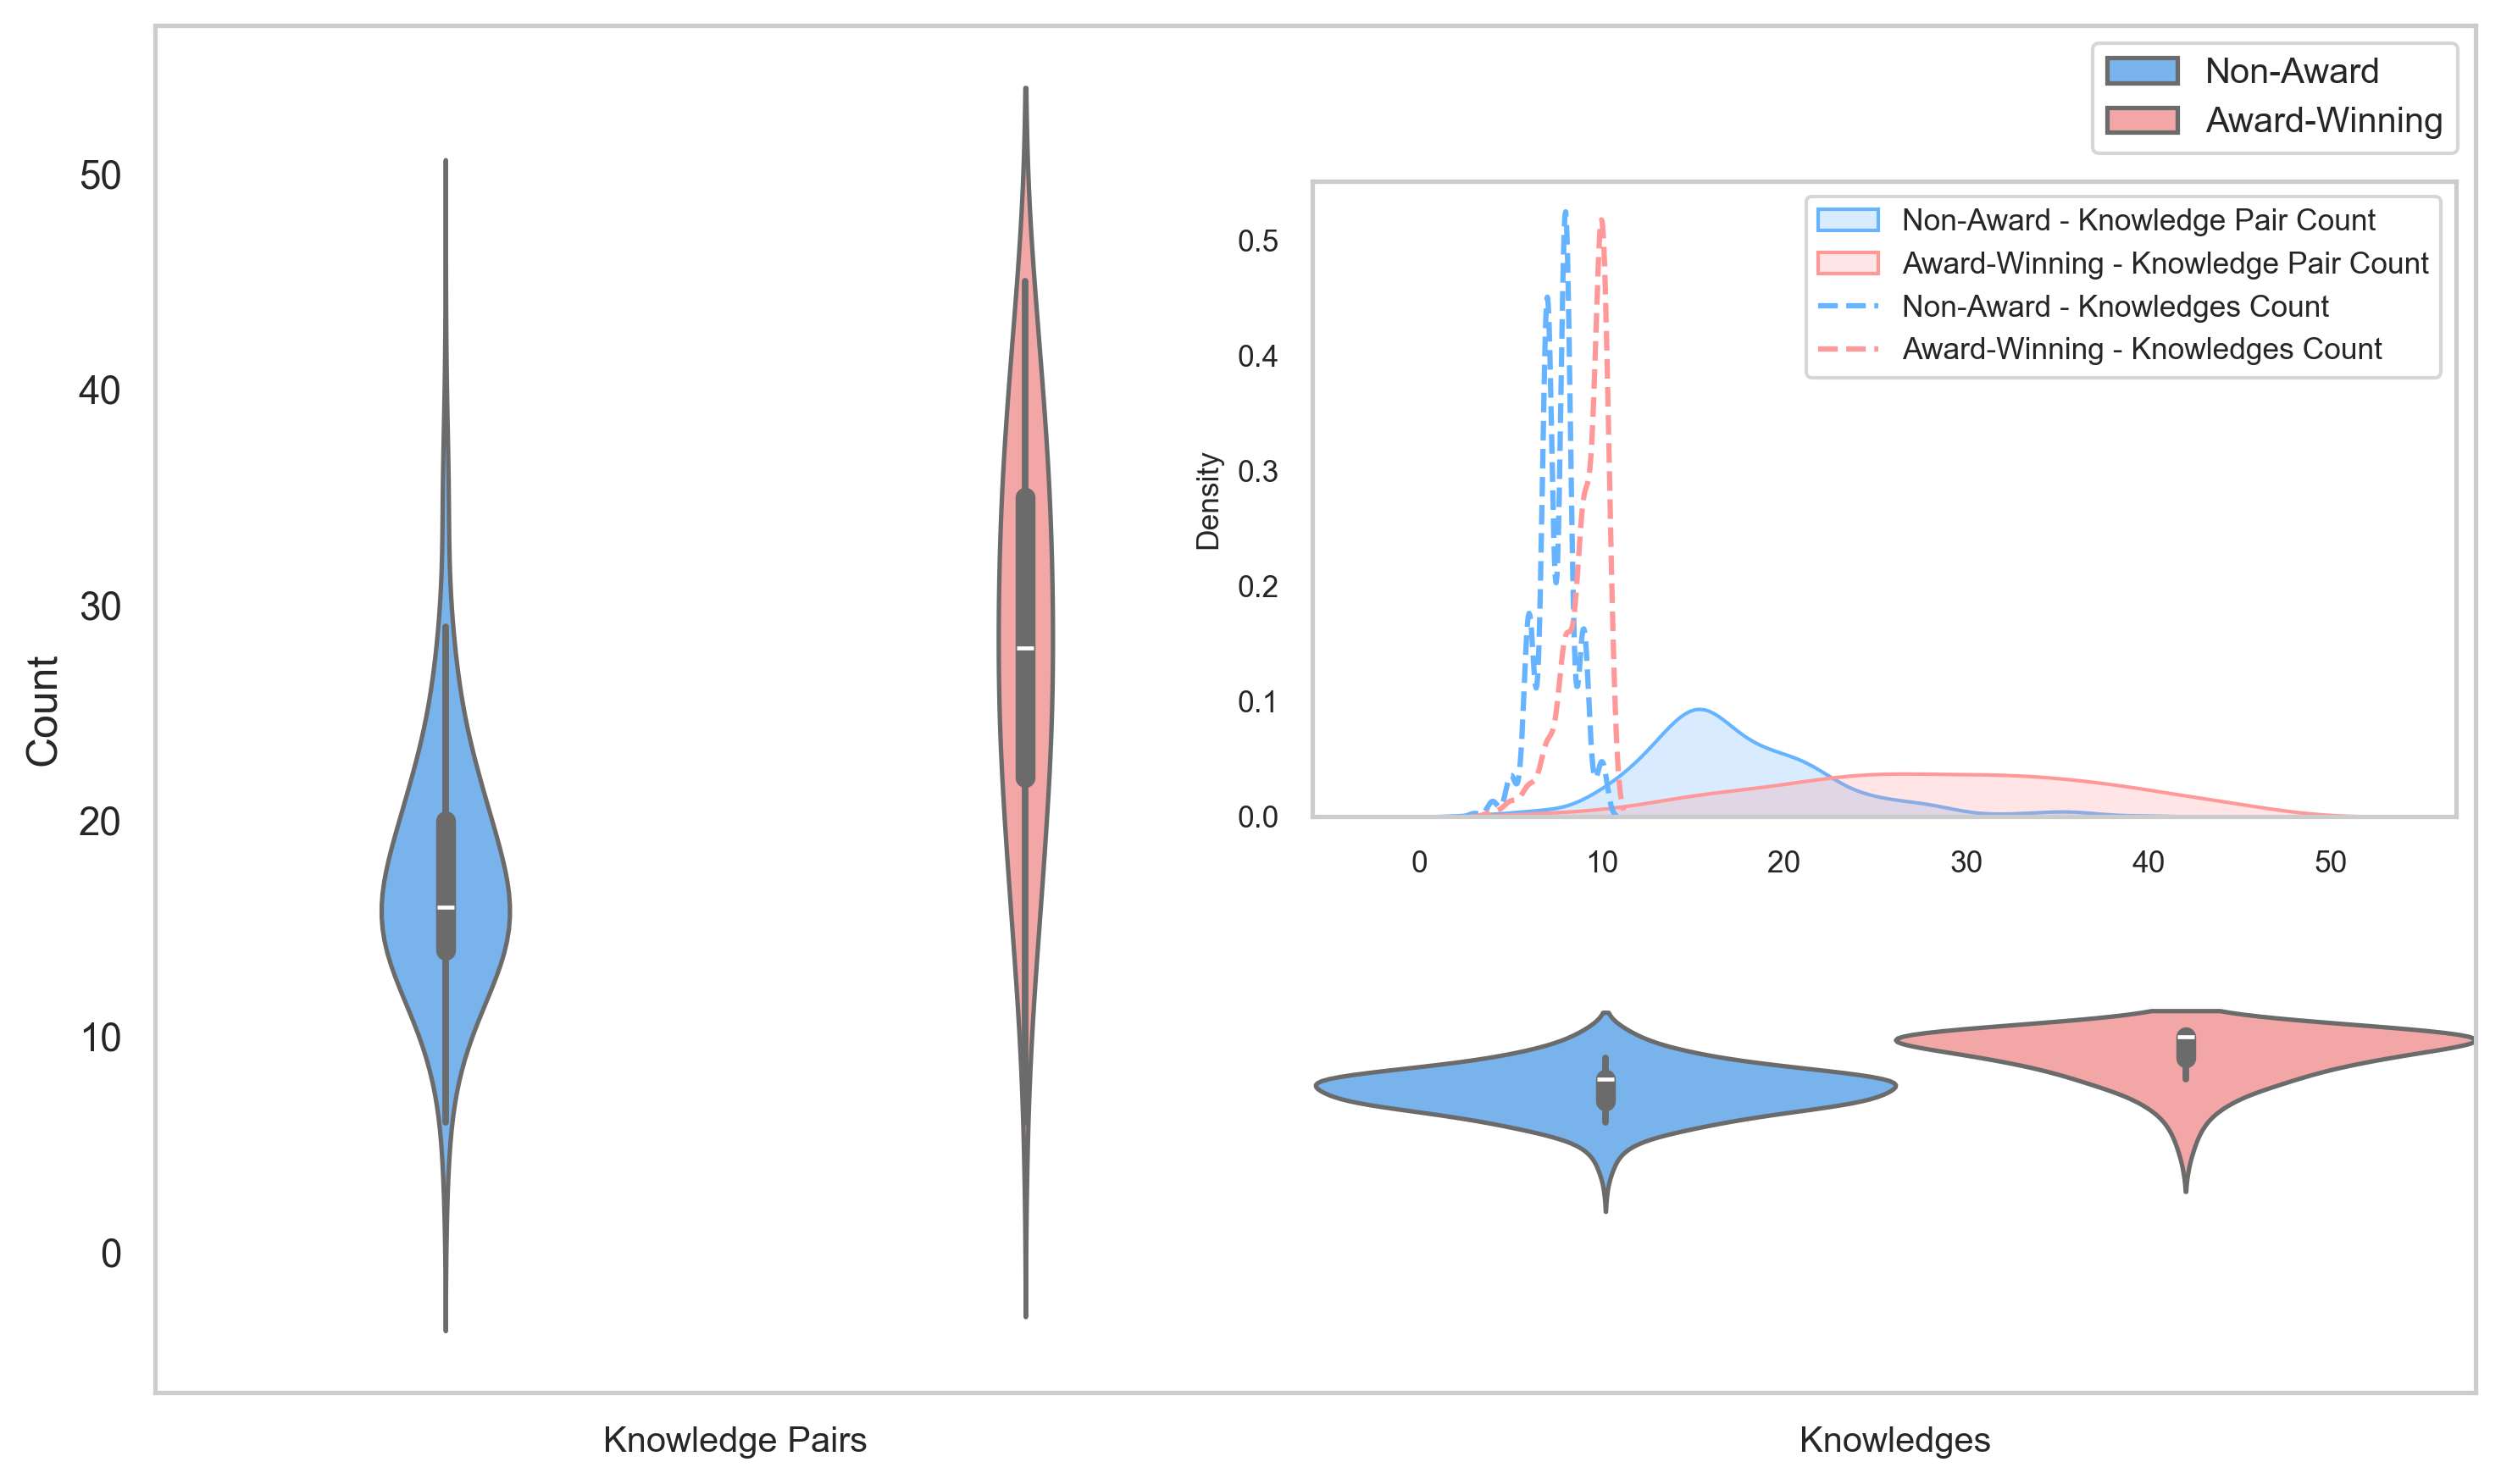

In [7]:
# 创建 DataFrame
df = pd.DataFrame({
    'Class': ['Class 0'] * len(award_0_knowledge_pair_count) +
             ['Class 1'] * len(award_1_knowledges_pair_count),

    'Pair Count': award_0_knowledge_pair_count + award_1_knowledges_pair_count,
    'Knowledges Count': award_0_knowledges_count + award_1_knowledges_count
})
# 将数据转换成长格式（long format）
df_melted = pd.melt(df, id_vars=['Class'],
                    value_vars=['Pair Count', 'Knowledges Count'],
                    var_name='Metric', value_name='Value')
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import to_rgba

# 设置风格
sns.set(style="whitegrid")

# 创建主图（小提琴图）
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 颜色方案
#palette = ["#66B3FF", "#FF9999"]
palette = [to_rgba('#66B3FF'), to_rgba('#FF9999', alpha=0.7)]
# **绘制小提琴图（作为主图）**
sns.violinplot(
    x="Metric", y="Value", hue="Class", data=df_melted,
    palette=palette, split=False, dodge=True, ax=ax,
    width=1, bw=0.5  # **增加小提琴宽度**
)

# **调整 X 轴标签**
ax.set_xticklabels(["Knowledge Pairs", "Knowledges"], fontsize=10)

# **移除 Y 轴标签，避免重复**
ax.set_ylabel("Count", fontsize=12)
ax.set_xlabel('')  # 隐藏 x 轴标签
# 重置图例标签
new_labels = ["Non-Award", "Award-Winning"]  # 替换原来的 "Class 0" 和 "Class 1"
handles, _ = ax.get_legend_handles_labels()
# **调整图例**
ax.legend(handles,new_labels,loc='best', fontsize=10, title="")
ax.grid(False)
# **添加标题**

# Distribution of Knowledge and Knowledge Pairs: Non-Award vs. Award-Winning Papers
ax.set_title("", fontsize=12, fontweight="bold")

# ----------------- **添加嵌入密度图（KDE）** -----------------
inset_ax = inset_axes(ax, width=4.5, height=2.5,  # **固定大小**
                      bbox_to_anchor=(0.6, 0.5, 0.4, 0.4),  # **调整位置**
                      bbox_transform=ax.transAxes)

# **绘制 KDE 密度曲线**
sns.kdeplot(df_melted[(df_melted['Metric'] == "Pair Count") & (df_melted['Class'] == "Class 0")]['Value'],
            shade=True, color=palette[0], label="Non-Award - Knowledge Pair Count", ax=inset_ax)
sns.kdeplot(df_melted[(df_melted['Metric'] == "Pair Count") & (df_melted['Class'] == "Class 1")]['Value'],
            shade=True, color=palette[1], label="Award-Winning - Knowledge Pair Count", ax=inset_ax)

sns.kdeplot(df_melted[(df_melted['Metric'] == "Knowledges Count") & (df_melted['Class'] == "Class 0")]['Value'],
            shade=False, linestyle="--", color=palette[0], label="Non-Award - Knowledges Count", ax=inset_ax)
sns.kdeplot(df_melted[(df_melted['Metric'] == "Knowledges Count") & (df_melted['Class'] == "Class 1")]['Value'],
            shade=False, linestyle="--", color=palette[1], label="Award-Winning - Knowledges Count", ax=inset_ax)

# **调整 KDE 图 X 轴 & Y 轴**
#inset_ax.set_xlabel("Value", fontsize=6)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("Density", fontsize=8.5)
inset_ax.legend(fontsize=8.5, title="")
inset_ax.tick_params(axis='x', labelsize=8.5)  # 调整 X 轴刻度字体大小
inset_ax.tick_params(axis='y', labelsize=8.5)  # 调整 Y 轴刻度字体大小
inset_ax.grid(False)  # 关闭网格线

# ----------------- **结束 inset** -----------------

# **调整整体布局，避免重叠**
plt.tight_layout()
plt.savefig('fig 5.png', dpi=300, format='png')
# **显示图形**
plt.show()


# 3D的去看距离和相似度的分布

C:\Users\wangzeren\AppData\Local\Temp\ipykernel_7360\3234613014.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrBr')  # 获取颜色映射


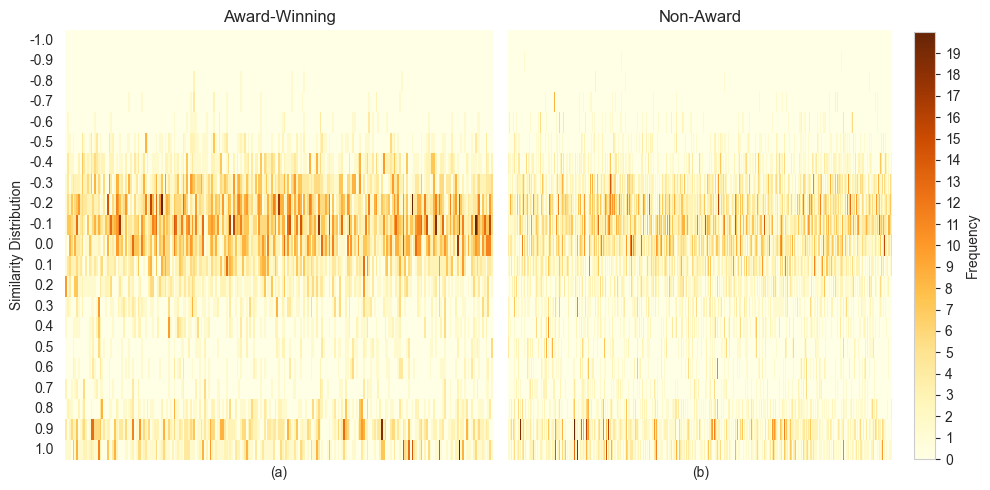

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
from matplotlib.colors import LogNorm, Normalize, PowerNorm, SymLogNorm, BoundaryNorm
# 定义一个函数来读取 CSV 文件并提取 similarity 列
def load_similarity_data(index):
    file_path = os.path.join(result_dir, f"{index}_similarity_distance.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        # 假设 similarity 列是数字类型的，提取该列
        similarity_data = df['similarity'].values
        return similarity_data
    else:
        print(f"文件 {file_path} 不存在!")
        return None
# 加载数据，得到两组数据
def load_data(indices):
    similarity_data_all = []
    for idx in indices:
        similarity_data = load_similarity_data(idx)
        if similarity_data is not None:
            similarity_data_all.append(similarity_data)
    return similarity_data_all
def process_and_generate_heatmap(data_0, decimal_places=1, num_bins=21,kedu_s=-1,kedu_e=1):
    num_samples = len(data_0)  # 样本的数量，对应行数
    num_bins = num_bins  # 设置列的数量，可以调整
    # 初始化一个矩阵，行数是样本数，列数是21（对应从-1到1的映射）
    heatmap_data = np.zeros((num_samples, num_bins))  # 初始化热力图矩阵
    # 刻度值从 -1 到 1，保留一位小数
    scale_values = np.round(np.linspace(kedu_s, kedu_e, num_bins), decimals=decimal_places)
    # 遍历每个样本，处理每个值
    for i, sample in enumerate(data_0):
        rounded_sample = np.round(sample, decimals=decimal_places)  # 四舍五入到指定小数位数
        value_counts = pd.Series(rounded_sample).value_counts().sort_index()  # 统计值的频率
        # 遍历每个值，计算对应的列索引
        for value, count in value_counts.items():
            # 查找该值在刻度中的位置
            if value in scale_values:
                col = np.where(scale_values == value)[0][0]  # 获取对应的列索引
                heatmap_data[i, col] = count  # 填充矩阵
    return heatmap_data, scale_values  # 返回刻度值用于设置x轴刻度
# 绘制四个热力图的函数
def plot_four_heatmaps(data_list, scale_values_list):
    # 创建一个2行2列的布局
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 根据需要调整figsize
    boundaries = np.arange(0, 16, 1) # 每个整数为一个区间
    norm = BoundaryNorm(boundaries, ncolors=256, clip=True)
    for i, ax in enumerate(axes.flat):
        # 每个subplot绘制一个热力图
        heatmap_data = data_list[i].T
        scale_values = scale_values_list[i]
        if i == 0:  #YlOrBr   YlGnBu
            sns.heatmap(heatmap_data, cmap='YlOrBr', cbar=False ,annot=False, ax=ax,norm=norm,robust=True) #vmin = 0, vmax = 16  norm=norm
            xlabel = "(a)"
            ylabel = "Similarity Distribution"
            title = "Award-Winning"
        elif i == 1:
            sns.heatmap(heatmap_data, cmap='YlOrBr', cbar=False ,annot=False, ax=ax,norm=norm,robust=True) #vmin = 0, vmax = 16  norm=norm
            xlabel = "(b)"
            ylabel = ""
            title = "Non-Award"

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if i == 0 or i == 2:
            yticks = np.arange(0.5, len(scale_values), 1)  # 将刻度设置为热力图块的中间位置
            ax.set_yticks(yticks)
            ax.set_yticklabels(scale_values, rotation=0, va='center')
            ax.tick_params(axis='y', labelsize=10, pad=5)  # 微调标签位置
        else:
            ax.set_yticks([])  # 隐藏y轴刻度
        ax.set_xticks([])  # 隐藏x轴刻度

    # 在右侧添加两个颜色条
    cmap = cm.get_cmap('YlOrBr')  # 获取颜色映射
    norm = mcolors.Normalize(vmin=0, vmax=20)  # 设置数据范围
    norm2 = mcolors.Normalize(vmin=0, vmax=1)  # 设置数据范围
    # 创建第一个（顶部）颜色条
    cbar_top = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes[1], orientation='vertical', fraction=0.05)
    cbar_top.set_ticks(np.arange(0, 20, 1))
    cbar_top.set_label('Frequency')
    plt.tight_layout()

    plt.savefig('heatmap.pdf', bbox_inches='tight')
    plt.show()
# 假设Excel文件名是 "data.xlsx"
excel_file = 'all_A_papers_innovation.xlsx'
result_dir = 'result'  # result 目录存放 CSV 文件
# 读取 Excel 文件
df = pd.read_excel(excel_file)
# 提取 award 为 0 和 1 的索引
award_0_indices = df[df['award'] == 0].index.tolist()
award_1_indices = df[df['award'] == 1].index.tolist()
# 获取award=0和award=1的所有数据
data_similarity_0 = load_data(award_0_indices)
data_similarity_1 = load_data(award_1_indices)
# 处理数据并生成热力图数据
heatmap_similarity_0, scale_similarity_0  = process_and_generate_heatmap(data_similarity_0, decimal_places=1)
heatmap_similarity_1, scale_similarity_1  = process_and_generate_heatmap(data_similarity_1, decimal_places=1)

data_list = [heatmap_similarity_1, heatmap_similarity_0]
scale_value_list = [scale_similarity_1, scale_similarity_0]
plot_four_heatmaps(data_list, scale_value_list)

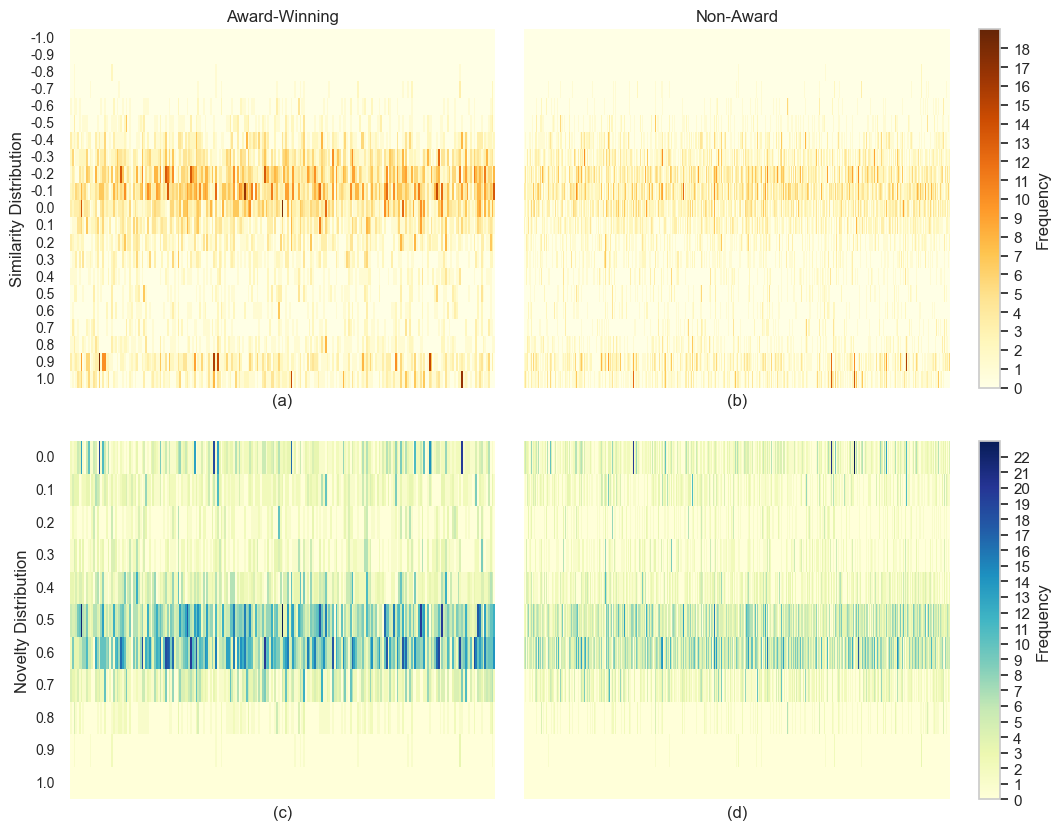

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
from matplotlib.colors import LogNorm, Normalize, PowerNorm, SymLogNorm, BoundaryNorm
from matplotlib.gridspec import GridSpec
# 定义一个函数来读取 CSV 文件并提取 similarity 列
def load_similarity_data(index):
    file_path = os.path.join(result_dir, f"{index}_similarity_distance.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        # 假设 similarity 列是数字类型的，提取该列
        similarity_data = df['similarity'].values
        return similarity_data
    else:
        print(f"文件 {file_path} 不存在!")
        return None
# 加载数据，得到两组数据
def load_data(indices):
    similarity_data_all = []
    innovation_data_all = []
    for idx in indices:
        similarity_data = load_similarity_data(idx)
        if similarity_data is not None:
            similarity_data_all.append(similarity_data)

            innovation_data = [(1-value)/2 for value in similarity_data]
            innovation_data_all.append(innovation_data)
    return similarity_data_all, innovation_data_all

def process_and_generate_heatmap(data_0, decimal_places=1, num_bins=21,kedu_s=-1,kedu_e=1):
    num_samples = len(data_0)  # 样本的数量，对应行数
    num_bins = num_bins  # 设置列的数量，可以调整
    # 初始化一个矩阵，行数是样本数，列数是21（对应从-1到1的映射）
    heatmap_data = np.zeros((num_samples, num_bins))  # 初始化热力图矩阵
    # 刻度值从 -1 到 1，保留一位小数
    scale_values = np.round(np.linspace(kedu_s, kedu_e, num_bins), decimals=decimal_places)
    # 遍历每个样本，处理每个值
    for i, sample in enumerate(data_0):
        rounded_sample = np.round(sample, decimals=decimal_places)  # 四舍五入到指定小数位数
        value_counts = pd.Series(rounded_sample).value_counts().sort_index()  # 统计值的频率
        # 遍历每个值，计算对应的列索引
        for value, count in value_counts.items():
            # 查找该值在刻度中的位置
            if value in scale_values:
                col = np.where(scale_values == value)[0][0]  # 获取对应的列索引
                heatmap_data[i, col] = count  # 填充矩阵
    return heatmap_data, scale_values  # 返回刻度值用于设置x轴刻度
# 绘制四个热力图的函数
def plot_four_heatmaps(data_list, scale_values_list):
    # 创建一个2行2列的布局
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(2, 3, width_ratios=[1, 1, 0.05], height_ratios=[1, 1], wspace=0.1, hspace=0.15)
    for i in range(4):
        row, col = divmod(i, 2)
        ax = fig.add_subplot(gs[row, col])
        heatmap_data = data_list[i].T
        scale_values = scale_values_list[i]
        # 设置标题、标签
        if i == 0:
            cmap = 'YlOrBr'  # YlOrBr  Oranges 可
            xlabel = "(a)"
            ylabel = "Similarity Distribution"
            title = "Award-Winning"
            max_value = 19
        elif i == 1:
            cmap = 'YlOrBr'  # YlOrBr
            xlabel = "(b)"
            ylabel = ""
            max_value = 19
            title = "Non-Award"
        elif i == 2:
            cmap = 'YlGnBu'  #YlGnBu
            xlabel = "(c)"
            ylabel = "Novelty Distribution"
            max_value = 23
            title = ""
        elif i == 3:
            cmap = 'YlGnBu'  #YlGnBu
            xlabel = "(d)"
            ylabel = ""
            max_value=23
            title = ""

        boundaries = np.arange(0, max_value, 1) # 每个整数为一个区间
        norm = BoundaryNorm(boundaries, ncolors=256, clip=True)
        sns.heatmap(heatmap_data, cmap=cmap, cbar=False ,annot=False, ax=ax,norm=norm,robust=True)

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if i == 0 or i == 2:
            yticks = np.arange(0.5, len(scale_values), 1)  # 将刻度设置为热力图块的中间位置
            ax.set_yticks(yticks)
            ax.set_yticklabels(scale_values, rotation=0, va='center')
            ax.tick_params(axis='y', labelsize=10, pad=5)  # 微调标签位置
        else:
            ax.set_yticks([])  # 隐藏y轴刻度
        ax.set_xticks([])  # 隐藏x轴刻度

    # 在右侧添加两个颜色条
    cmap = cm.get_cmap('YlOrBr')  # 获取颜色映射
    norm = mcolors.Normalize(vmin=0, vmax=19)  # 设置数据范围
    # 创建第一个（顶部）颜色条
    cbar_ax1 = fig.add_subplot(gs[0, 2])
    cbar_top = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax1, orientation='vertical')
    cbar_top.set_ticks(np.arange(0, 19, 1))
    cbar_top.set_label('Frequency')

    #颜色条2（第二行）
    cmap = cm.get_cmap('YlGnBu')
    norm2 = mcolors.Normalize(vmin=0, vmax=23)
    cbar_ax2 = fig.add_subplot(gs[1, 2])
    cbar2 = fig.colorbar(cm.ScalarMappable(norm=norm2, cmap=cmap), cax=cbar_ax2, orientation='vertical')
    cbar2.set_ticks(np.arange(0, 23, 1))
    cbar2.set_label('Frequency')

    plt.tight_layout()

    plt.savefig('heatmap.png', bbox_inches='tight')
    plt.show()
# 假设Excel文件名是 "data.xlsx"
excel_file = 'all_A_papers_innovation.xlsx'
#result_dir = 'result'  # result 目录存放 CSV 文件
result_dir = 'roberta/global_loss'
# 读取 Excel 文件
df = pd.read_excel(excel_file)
# 提取 award 为 0 和 1 的索引
award_0_indices = df[df['award'] == 0].index.tolist()
award_1_indices = df[df['award'] == 1].index.tolist()
# 获取award=0和award=1的所有数据
data_similarity_0,data_innovation_0 = load_data(award_0_indices)
data_similarity_1,data_innovation_1 = load_data(award_1_indices)
# 处理数据并生成热力图数据
heatmap_similarity_0, scale_similarity_0  = process_and_generate_heatmap(data_similarity_0, decimal_places=1)
heatmap_similarity_1, scale_similarity_1  = process_and_generate_heatmap(data_similarity_1, decimal_places=1)
heatmap_innovation_0, scale_innovation_0  = process_and_generate_heatmap(data_innovation_0, decimal_places=1, kedu_s=0,kedu_e=1,num_bins=11)
heatmap_innovation_1, scale_innovation_1  = process_and_generate_heatmap(data_innovation_1, decimal_places=1, kedu_s=0,kedu_e=1,num_bins=11)

data_list = [heatmap_similarity_1, heatmap_similarity_0, heatmap_innovation_1, heatmap_innovation_0]
scale_value_list = [scale_similarity_1, scale_similarity_0, scale_innovation_1, scale_innovation_0]
plot_four_heatmaps(data_list, scale_value_list)

In [35]:
from collections import Counter

def max_frequency_in_nested(arr):
    max_freq = 0  # 用来存储最大频率
    for sublist in arr:
        # 对每个子数组中的元素保留一位小数
        sublist = [round(x, 1) for x in sublist]
        count = Counter(sublist)  # 统计子数组中元素的频率
        max_freq_in_sublist = max(count.values())  # 获取子数组内最大频率
        max_freq = max(max_freq, max_freq_in_sublist)  # 更新最大频率
    return max_freq

# 测试示例
arr = [[1, 1, 2], [2, 2, 2], [3, 1, 3]]
print(max_frequency_in_nested(data_innovation_1))  # 输出: 3


23


In [16]:
import pandas as pd
# 设置显示浮动数值为常规小数形式
pd.options.display.float_format = '{:.4f}'.format
excel_file = 'all_A_papers_innovation.xlsx'
df = pd.read_excel(excel_file)
award_0_indices = df[df['award'] == 0].index.tolist()
award_1_indices = df[df['award'] == 1].index.tolist()

columns = ['index','similarity', 'median_value', 'avg','influential', 'citationCount','number','innovation']
award_0_df = pd.DataFrame(columns=columns)
# 遍历award_0_indices，读取{i}_similarity_distance.csv
for idx in award_0_indices:
    #file_path = f'result/{idx}_similarity_distance.csv'
    file_path = f'roberta/global_loss/{idx}_similarity_distance.csv'

    index = idx
    influentialCitationCount,citationCount,year,innovation = df.loc[idx, ['influentialCitationCount', 'citationCount', 'year','innovation']]

    data = pd.read_csv(file_path)
    data['similarity'] = data['similarity'].round(4)
    #data['distance'] = data['distance'].round(4)
    # 单独提取 similarity 和 distance 列进行排序
    sorted_similarity = data['similarity'].sort_values(ascending=True)  # similarity 从小到大排序
    #sorted_distance = data['distance'].sort_values(ascending=False)  # distance 从大到小排序
    combination_number=len(data)

    # 异常值是，  相似度越小的越多越好-----距离越大的越多越好
    s_n_percentile = 0.5  # 50%的分位点越小越好，  ==========所以后面从小到大排序

    similarity_value = sorted_similarity.quantile(s_n_percentile)
    median_value = sorted_similarity.quantile(0.5)
    avg = sorted_similarity.mean()
    #distance_value = sorted_distance.quantile(d_n_percentile)
    new_row=[index, similarity_value, median_value, avg,influentialCitationCount,citationCount,combination_number,innovation]
    award_0_df.loc[len(award_0_df)] = new_row

In [17]:
# 相似度越小越好，距离越大越好
#award_0_df = award_0_df.sort_values(by=['similarity','distance'], ascending=[True,False])
award_0_df = award_0_df.sort_values(by=['innovation','similarity'], ascending=[False,True])
# award_0_df = award_0_df.sort_values(by=['similarity'], ascending=[True,False])
print(award_0_df.head(20).to_string(index=False))

    index  similarity  median_value     avg  influential  citationCount  number  innovation
 532.0000     -0.0547       -0.0547  0.0137      27.0000       440.0000 45.0000     22.1919
 482.0000     -0.0779       -0.0779  0.0055     188.0000       926.0000 41.0000     20.3876
 632.0000     -0.1174       -0.1174 -0.0192      15.0000       571.0000 39.0000     19.8749
 554.0000     -0.0983       -0.0983 -0.0051      67.0000      1345.0000 37.0000     18.5951
 678.0000     -0.0884       -0.0884  0.1101      69.0000      1168.0000 40.0000     17.7990
 717.0000     -0.1299       -0.1299  0.0276      69.0000       341.0000 36.0000     17.5033
 550.0000     -0.1441       -0.1441 -0.0217     165.0000      2668.0000 34.0000     17.3683
 319.0000      0.0051        0.0051  0.1252      85.0000       374.0000 39.0000     17.0583
1040.0000     -0.1083       -0.1083  0.0384     116.0000       575.0000 35.0000     16.8279
 649.0000     -0.1042       -0.1042 -0.0161     172.0000      1046.0000 33.0000 

In [3]:
import os
import pandas as pd

# 定义目录路径
data_dir = 'data'

# 初始化行数汇总
total_lines = 0

# 遍历0到1184的数字
for i in range(1185):
    # 构建文件名
    filename = f"{i}_ref.csv"
    file_path = os.path.join(data_dir, filename)

    # 检查文件是否存在
    if os.path.exists(file_path):
        try:
            # 使用 pandas 读取 CSV 文件，指定错误处理方式
            df = pd.read_csv(file_path, encoding='utf-8')  # 或者使用 'replace'
            line_count = len(df)
            total_lines += line_count
            print(f"{filename} 行数: {line_count}")
        except Exception as e:
            print(f"文件 {filename} 读取失败: {e}")
    else:
        print(f"文件 {filename} 不存在")

# 输出总行数
print(f"所有文件的总行数: {total_lines}")


文件 0_ref.csv 读取失败: 'utf-8' codec can't decode bytes in position 1272-1273: invalid continuation byte
1_ref.csv 行数: 44
2_ref.csv 行数: 17
3_ref.csv 行数: 15
4_ref.csv 行数: 8
5_ref.csv 行数: 27
6_ref.csv 行数: 23
7_ref.csv 行数: 7
8_ref.csv 行数: 18
9_ref.csv 行数: 4
10_ref.csv 行数: 8
11_ref.csv 行数: 21
12_ref.csv 行数: 9
13_ref.csv 行数: 19
14_ref.csv 行数: 20
15_ref.csv 行数: 13
16_ref.csv 行数: 18
17_ref.csv 行数: 16
18_ref.csv 行数: 13
19_ref.csv 行数: 7
20_ref.csv 行数: 9
21_ref.csv 行数: 22
22_ref.csv 行数: 10
23_ref.csv 行数: 8
24_ref.csv 行数: 23
25_ref.csv 行数: 27
26_ref.csv 行数: 23
27_ref.csv 行数: 3
28_ref.csv 行数: 18
29_ref.csv 行数: 26
30_ref.csv 行数: 21
31_ref.csv 行数: 59
32_ref.csv 行数: 27
33_ref.csv 行数: 32
34_ref.csv 行数: 14
35_ref.csv 行数: 17
36_ref.csv 行数: 15
37_ref.csv 行数: 8
38_ref.csv 行数: 7
39_ref.csv 行数: 11
40_ref.csv 行数: 28
41_ref.csv 行数: 20
42_ref.csv 行数: 20
43_ref.csv 行数: 6
44_ref.csv 行数: 22
45_ref.csv 行数: 6
46_ref.csv 行数: 29
47_ref.csv 行数: 12
48_ref.csv 行数: 14
49_ref.csv 行数: 2
50_ref.csv 行数: 9
51_ref.csv 行数: 15
52_re

# 统计各个会议的期刊、参考文献、被引等信息